In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.join(os.getcwd(), ".."))

from numcompute_stream.io import load_csv, generate_synthetic_dataset
from numcompute_stream.preprocessing import StandardScaler
from numcompute_stream.tree import DecisionTreeClassifier
from numcompute_stream.ensemble import RandomForestClassifier
from numcompute_stream.pipeline import Pipeline
from numcompute_stream.stream import StreamTrainer
from numcompute_stream.metrics import (
    StreamingAccuracy,
    StreamingConfusionMatrix,
    StreamingPrecisionRecallF1,
)
import numcompute_stream.visualise as vis

print("NumCompute Stream loaded ✓")

NumCompute Stream loaded ✓


In [2]:
# ==========================================================
# 1. Load Dataset via Custom I/O Pipeline
# ==========================================================

DATA_PATH = "../data/synthetic_farm.csv"

if not os.path.exists(DATA_PATH):
    generate_synthetic_dataset(
        n_samples=1000,
        n_features=6,
        n_classes=3,
        random_state=42,
        save_path=DATA_PATH,
    )

X, y, feature_names = load_csv(
    DATA_PATH,
    has_header=True,
    target_col=-1,
)

y = y.astype(int)

print(f"Dataset shape: X={X.shape}")
print(f"Unique classes: {np.unique(y)}")
print(f"Feature names: {feature_names}")
print(
    f"Class distribution: "
    f"{dict(zip(*np.unique(y, return_counts=True)))}"
)

Dataset shape: X=(1000, 6)
Unique classes: [0 1 2]
Feature names: ['feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5']
Class distribution: {np.int64(0): np.int64(231), np.int64(1): np.int64(443), np.int64(2): np.int64(326)}


In [3]:
# ==========================================================
# 2. Split Into Streaming Chunks
# ==========================================================

N_CHUNKS = 10

chunks = list(
    StreamTrainer.make_chunks(
        X,
        y,
        n_chunks=N_CHUNKS,
        shuffle=True,
        random_state=0,
    )
)

print(f"\nCreated {len(chunks)} chunks")

for i, (Xc, yc) in enumerate(chunks):
    print(
        f"Chunk {i:2d}: "
        f"{Xc.shape[0]} samples | "
        f"classes {np.unique(yc)}"
    )


Created 10 chunks
Chunk  0: 100 samples | classes [0 1 2]
Chunk  1: 100 samples | classes [0 1 2]
Chunk  2: 100 samples | classes [0 1 2]
Chunk  3: 100 samples | classes [0 1 2]
Chunk  4: 100 samples | classes [0 1 2]
Chunk  5: 100 samples | classes [0 1 2]
Chunk  6: 100 samples | classes [0 1 2]
Chunk  7: 100 samples | classes [0 1 2]
Chunk  8: 100 samples | classes [0 1 2]
Chunk  9: 100 samples | classes [0 1 2]


In [4]:
# ==========================================================
# 3. Train Models Incrementally
# ==========================================================

tree_model = DecisionTreeClassifier(
    max_depth=5,
    criterion="gini",
    random_state=0,
)

tree_trainer = StreamTrainer(
    tree_model,
    scaler=StandardScaler(),
)

rf_pipe = Pipeline([
    ("scale", StandardScaler()),
    (
        "rf",
        RandomForestClassifier(
            n_estimators=10,
            max_depth=5,
            random_state=0,
        ),
    ),
])

rf_trainer = StreamTrainer(rf_pipe)

for Xc, yc in chunks:
    tree_trainer.fit_chunk(Xc, yc)
    rf_trainer.fit_chunk(Xc, yc)

print("\nTraining complete.")

print(
    "Decision Tree final cumulative accuracy:",
    f"{tree_trainer.chunk_logs_[-1]['cumulative_accuracy']:.4f}",
)

print(
    "Random Forest final cumulative accuracy:",
    f"{rf_trainer.chunk_logs_[-1]['cumulative_accuracy']:.4f}",
)



Training complete.
Decision Tree final cumulative accuracy: 0.8990
Random Forest final cumulative accuracy: 0.9160


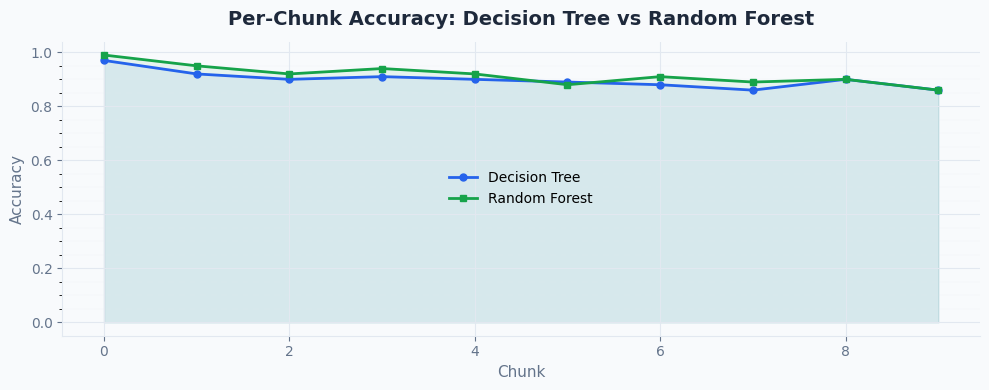

In [5]:
# ==========================================================
# 4. Visualise Accuracy Over Chunks
# ==========================================================
import matplotlib.pyplot as plt

tree_acc = tree_trainer.get_metric_history("accuracy")
rf_acc = rf_trainer.get_metric_history("accuracy")

fig, ax = vis.compare_models(
    tree_acc,
    rf_acc,
    labels=("Decision Tree", "Random Forest"),
    title="Per-Chunk Accuracy: Decision Tree vs Random Forest",
    ylabel="Accuracy",
)

plt.show()


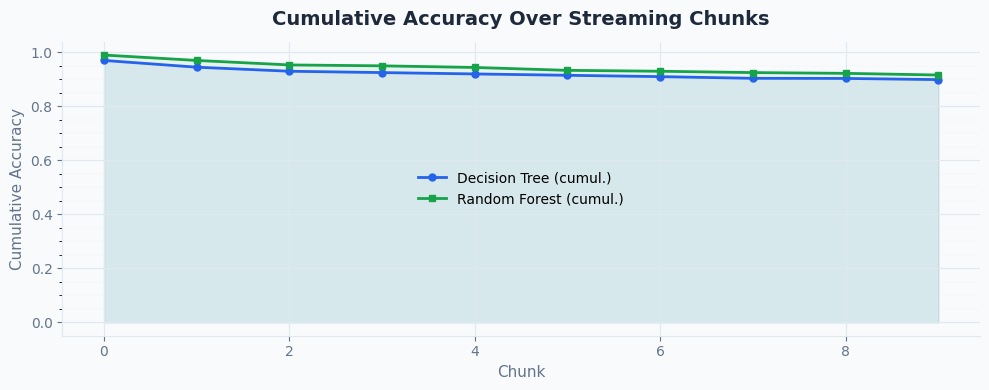

In [6]:
# ==========================================================
# 5. Cumulative Accuracy Trend
# ==========================================================

tree_cum = tree_trainer.get_metric_history(
    "cumulative_accuracy"
)

rf_cum = rf_trainer.get_metric_history(
    "cumulative_accuracy"
)

fig, ax = vis.compare_models(
    tree_cum,
    rf_cum,
    labels=(
        "Decision Tree (cumul.)",
        "Random Forest (cumul.)",
    ),
    title="Cumulative Accuracy Over Streaming Chunks",
    ylabel="Cumulative Accuracy",
)

plt.show()


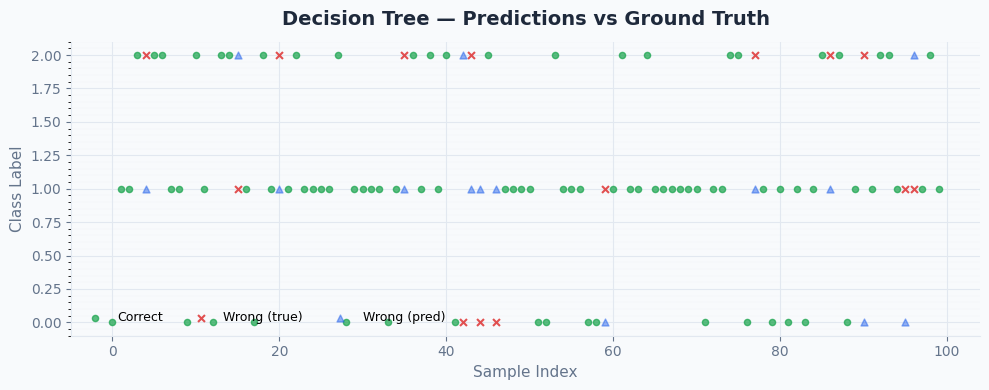

In [7]:
# ==========================================================
# 6. Predictions vs Ground Truth
# ==========================================================

X_last, y_last = chunks[-1]

tree_preds = tree_trainer.predict(X_last)

fig, ax = vis.plot_predictions_vs_ground_truth(
    y_last,
    tree_preds,
    title="Decision Tree — Predictions vs Ground Truth",
)

plt.show()


In [8]:
# ==========================================================
# 7. Streaming Precision / Recall / F1
# ==========================================================

prf_tree = StreamingPrecisionRecallF1(
    classes=[0, 1, 2]
)

prf_rf = StreamingPrecisionRecallF1(
    classes=[0, 1, 2]
)

for Xc, yc in chunks:
    prf_tree.update(
        yc,
        tree_trainer.predict(Xc),
    )

    prf_rf.update(
        yc,
        rf_trainer.predict(Xc),
    )

res_tree = prf_tree.result()
res_rf = prf_rf.result()

print("\n=== Decision Tree ===")
print(f"Macro Precision : {res_tree['macro_precision']:.4f}")
print(f"Macro Recall    : {res_tree['macro_recall']:.4f}")
print(f"Macro F1        : {res_tree['macro_f1']:.4f}")

print("\n=== Random Forest ===")
print(f"Macro Precision : {res_rf['macro_precision']:.4f}")
print(f"Macro Recall    : {res_rf['macro_recall']:.4f}")
print(f"Macro F1        : {res_rf['macro_f1']:.4f}")



=== Decision Tree ===
Macro Precision : 0.8248
Macro Recall    : 0.8282
Macro F1        : 0.8257

=== Random Forest ===
Macro Precision : 0.8605
Macro Recall    : 0.8625
Macro F1        : 0.8611


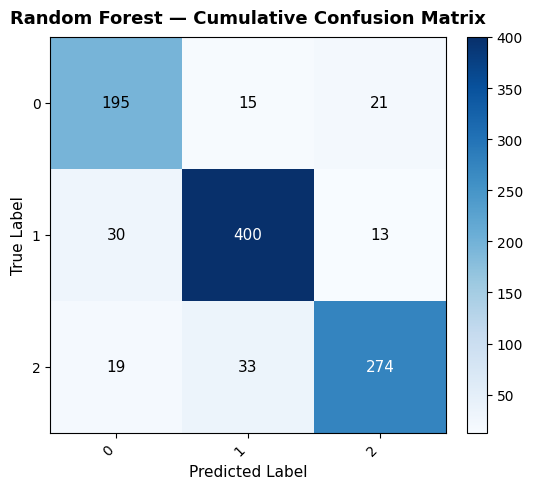


Confusion Matrix:
[[195  15  21]
 [ 30 400  13]
 [ 19  33 274]]


In [9]:
# ==========================================================
# 8. Confusion Matrix
# ==========================================================

cm_rf = StreamingConfusionMatrix(
    classes=[0, 1, 2]
)

for Xc, yc in chunks:
    cm_rf.update(
        yc,
        rf_trainer.predict(Xc),
    )

matrix, classes = cm_rf.result()

fig, ax = vis.plot_confusion_matrix(
    matrix,
    classes,
    title="Random Forest — Cumulative Confusion Matrix",
)

plt.show()

print("\nConfusion Matrix:")
print(matrix)


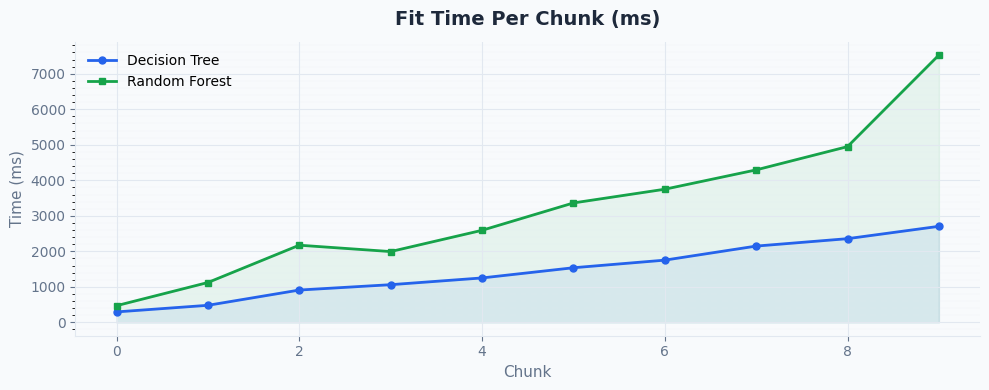


=== STREAMING SUMMARY ===
Model                      Chunks   FinalCumAcc   MacroF1
------------------------------------------------------------
Decision Tree                  10        0.8990    0.8257
Random Forest                  10        0.9160    0.8611


In [10]:
# ==========================================================
# 9. Training Time Per Chunk
# ==========================================================

tree_times = tree_trainer.get_metric_history(
    "fit_time_s"
)

rf_times = rf_trainer.get_metric_history(
    "fit_time_s"
)

fig, ax = vis.compare_models(
    [t * 1000 for t in tree_times],
    [t * 1000 for t in rf_times],
    labels=("Decision Tree", "Random Forest"),
    title="Fit Time Per Chunk (ms)",
    ylabel="Time (ms)",
)

plt.show()

# ==========================================================
# 10. Summary Table
# ==========================================================

print("\n=== STREAMING SUMMARY ===")
print(
    f"{'Model':<25}"
    f"{'Chunks':>8}"
    f"{'FinalCumAcc':>14}"
    f"{'MacroF1':>10}"
)

print("-" * 60)

print(
    f"{'Decision Tree':<25}"
    f"{len(tree_trainer.chunk_logs_):>8}"
    f"{tree_trainer.chunk_logs_[-1]['cumulative_accuracy']:>14.4f}"
    f"{res_tree['macro_f1']:>10.4f}"
)

print(
    f"{'Random Forest':<25}"
    f"{len(rf_trainer.chunk_logs_):>8}"
    f"{rf_trainer.chunk_logs_[-1]['cumulative_accuracy']:>14.4f}"
    f"{res_rf['macro_f1']:>10.4f}"
)